# Mapping the Potential Destructive Power of Wildfires Using Machine Learning
---
## Module 8: *Evaluation and Visualization*
##### Version Number: 2.0
---
### Contents  
> 1. *Generate Case Study Predictions*
> 2. *Geospatial Visualization* (in progress)
---
### Notes
This section applies the trained models to predict wildfire severity in real-world scenarios including
- #### Palisades Fire (January 2025)  
It evaluates and compare the performance of three classification models:
- **XGBoost** (multi-class classification)
- **Random Forest**
- **K-Nearest Neighbors (KNN)**
---
### Inputs
`X.csv` Model data
`y.csv` Target data
`details.csv` details reguarding data

---
### Outputs  
- `predictions.csv` Dataset containing prediction models composed of a categorical prediction 0,1,2 to be used for interpolation in ArcGIS.
---
### User Created Dependencies  

In [1]:
# Add the parent directory to the system path so "src" can be found
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

# user built utilities
from src.plot_utils import plot_map
from src.plot_utils import individual_plot_map
from src.plot_utils import interpolate_idw
from src.plot_utils import interpolate_idw2

---
### Third Party Dependencies

In [2]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modeling libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import RidgeClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.model_selection import train_test_split

# Geospatial libraries
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.lines as mlines  # For custom map legends

from datetime import timedelta

In [3]:
# first day to analyze in weather dataset
FIRST_DATE = pd.to_datetime('2018-01-01').date()

# last day to analyze in weather dataset
LAST_DATE = pd.to_datetime('2024-12-31').date()

In [4]:
# Features and labels
X = pd.read_csv('../data/processed/X.csv')
y = pd.read_csv('../data/processed/y.csv').squeeze()  # Load as Series
details = pd.read_csv('../data/processed/details.csv')


In [5]:
y.value_counts()

Target
0    13944
2     4776
1     3426
Name: count, dtype: int64

In [6]:
details['Date'] = pd.to_datetime(details['Date']).dt.date

# Boolean mask for the date window
mask = (details['Date'] >= FIRST_DATE) & (details['Date'] <= LAST_DATE)

# MODEL (inside date range)
model_details = details.loc[mask]
model_X = X.loc[mask]
model_y = y.loc[mask]

# PAL (outside date range)
pal_details = details.loc[~mask]
pal_X = X.loc[~mask]
pal_y = y.loc[~mask]

### 1.1 Build Models

In [7]:
model_parameters = pd.read_csv('../data/processed/model_parameters.csv', index_col=0)

RF_parameters = model_parameters.loc['RandomForest'].dropna().to_dict()
XGB_parameters = model_parameters.loc['XGBoost'].dropna().to_dict()
Knn_parameters = model_parameters.loc['KNN'].dropna().to_dict()
optimal_learning_rate = XGB_parameters['learning_rate']

# Helper function to convert to int if possible
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}

RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
Knn_parameters = convert_to_int(Knn_parameters)

XGB_parameters['learning_rate'] = optimal_learning_rate
#optimal_learning_rate = XGB_parameters['learning_rate']

In [8]:
# Helper function to convert to int if possible
def convert_to_int(d):
    return {k: int(float(v)) if str(v).replace('.', '', 1).isdigit() else v for k, v in d.items()}

RF_parameters = convert_to_int(RF_parameters)
XGB_parameters = convert_to_int(XGB_parameters)
Knn_parameters = convert_to_int(Knn_parameters)


In [9]:
display(RF_parameters)
display(XGB_parameters)
display(Knn_parameters)

{'n_estimators': 150,
 'max_depth': 20,
 'min_samples_split': 5,
 'max_features': 'log2',
 'class_weight': 'balanced'}

{'n_estimators': 200,
 'max_depth': 6,
 'objective': 'multi:softmax',
 'num_class': 3,
 'learning_rate': 0}

{'n_neighbors': 1, 'weights': 'uniform'}

In [10]:
# Build Final tuned models
optimum_xgb_model = xgb.XGBClassifier(**XGB_parameters)
optimum_rf = RandomForestClassifier(**RF_parameters)
optimum_knn = KNeighborsClassifier(**Knn_parameters)

### 1.2 Train Models

In [11]:
X_train, X_test, y_train, y_test = train_test_split(model_X, model_y, test_size=0.2, random_state=14)

#### (Optional) Downsize Majority Class for processing power

In [12]:
optimum_xgb_model.fit(X_train, y_train)
optimum_rf.fit(X_train, y_train)
optimum_knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=1)

In [13]:
rf_importances = optimum_rf.feature_importances_
for name, importance in zip(X.columns, rf_importances):
    print(f"{name}: {importance:.4f}")

Unnamed: 0 x Avg Air Temp (F) 7 Day Avg: 0.1843
Unnamed: 0 x Season: 0.1346
Unnamed: 0 x Avg Vap Pres (mBars): 0.1376
Unnamed: 0 x 2-Year Avg Fires: 0.0832
Unnamed: 0 x Avg Wind Speed (mph) 7 Day Avg: 0.0862
ETo (in) x Season: 0.0280
Unnamed: 0 x Avg Rel Hum (%) 7 Day Avg: 0.0655
Unnamed: 0 x Avg Wind Speed (mph): 0.0568
Avg Air Temp (F) 7 Day Avg: 0.0321
ETo (in) x Avg Soil Temp (F): 0.0271
Avg Vap Pres (mBars) x Season: 0.0345
ETo (in) x Avg Vap Pres (mBars): 0.0306
Unnamed: 0 x Mean Income: 0.0474
ETo (in) x 2-Year Avg Fires: 0.0519


In [14]:
xgb_importances = optimum_xgb_model.feature_importances_
for name, importance in zip(X.columns, xgb_importances):
    print(f"{name}: {importance:.4f}")

Unnamed: 0 x Avg Air Temp (F) 7 Day Avg: 0.6303
Unnamed: 0 x Season: 0.1666
Unnamed: 0 x Avg Vap Pres (mBars): 0.0162
Unnamed: 0 x 2-Year Avg Fires: 0.0392
Unnamed: 0 x Avg Wind Speed (mph) 7 Day Avg: 0.0016
ETo (in) x Season: 0.0176
Unnamed: 0 x Avg Rel Hum (%) 7 Day Avg: 0.0167
Unnamed: 0 x Avg Wind Speed (mph): 0.0074
Avg Air Temp (F) 7 Day Avg: 0.0220
ETo (in) x Avg Soil Temp (F): 0.0239
Avg Vap Pres (mBars) x Season: 0.0082
ETo (in) x Avg Vap Pres (mBars): 0.0171
Unnamed: 0 x Mean Income: 0.0092
ETo (in) x 2-Year Avg Fires: 0.0241


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [16]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"Evaluation for {name}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.3f}")
    print(f"Precision: {precision_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"Recall:    {recall_score(y_test, y_pred, average='weighted'):.3f}")
    print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted'):.3f}")
    print("---- Classification Report ----")
    print(classification_report(y_test, y_pred))
    print("\n")

In [17]:
evaluate_model(optimum_xgb_model, X_test, y_test, "XGBoost")

Evaluation for XGBoost
Accuracy:  0.550
Precision: 0.303
Recall:    0.550
F1 Score:  0.390
---- Classification Report ----
              precision    recall  f1-score   support

           0       0.55      1.00      0.71      1999
           1       0.00      0.00      0.00       664
           2       0.00      0.00      0.00       971

    accuracy                           0.55      3634
   macro avg       0.18      0.33      0.24      3634
weighted avg       0.30      0.55      0.39      3634





C:\Users\dusti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dusti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dusti\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\dusti\anaconda3\Lib\site-packag

In [18]:
evaluate_model(optimum_rf, X_test, y_test, "Random Forest")

Evaluation for Random Forest
Accuracy:  0.945
Precision: 0.945
Recall:    0.945
F1 Score:  0.945
---- Classification Report ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       0.86      0.83      0.85       664
           2       0.89      0.91      0.90       971

    accuracy                           0.94      3634
   macro avg       0.92      0.91      0.92      3634
weighted avg       0.94      0.94      0.94      3634





In [19]:
evaluate_model(optimum_knn, X_test, y_test, "KNN")

Evaluation for KNN
Accuracy:  0.938
Precision: 0.938
Recall:    0.938
F1 Score:  0.938
---- Classification Report ----
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       0.83      0.83      0.83       664
           2       0.88      0.88      0.88       971

    accuracy                           0.94      3634
   macro avg       0.91      0.90      0.91      3634
weighted avg       0.94      0.94      0.94      3634





### 1.3 Generate Predictions

In [20]:
# Palisades Fire (January 2025)
pal_xgb_predictions = pd.DataFrame(optimum_xgb_model.predict(pal_X))
pal_rf_predictions = pd.DataFrame(optimum_rf.predict(pal_X))
pal_knn_predictions = pd.DataFrame(optimum_knn.predict(pal_X))

# Apply reverse mapping to all prediction sets
pal_xgb_predictions[0] = pal_xgb_predictions[0].replace(label_map)
pal_rf_predictions[0] = pal_rf_predictions[0].replace(label_map)
pal_knn_predictions[0] = pal_knn_predictions[0].replace(label_map)

In [21]:
pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
pal_details['Prediction KNN'] = pal_knn_predictions[0].values
pal_details['Prediction RF']  = pal_rf_predictions[0].values

C:\Users\dusti\AppData\Local\Temp\ipykernel_61068\1898117021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Prediction XGB'] = pal_xgb_predictions[0].values
C:\Users\dusti\AppData\Local\Temp\ipykernel_61068\1898117021.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Prediction KNN'] = pal_knn_predictions[0].values
C:\Users\dusti\AppData\Local\Temp\ipykernel_61068\1898117021.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try

In [22]:
pal_specific_date = pd.to_datetime('2025-01-07').date()
pal_specific_date_end = pd.to_datetime('2025-01-12').date()

pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date

C:\Users\dusti\AppData\Local\Temp\ipykernel_61068\1497241495.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pal_details['Date'] = pd.to_datetime(pal_details['Date']).dt.date


In [23]:
pal_predictions = pal_details[pal_details['Date'] == pal_specific_date]

In [24]:
forward = timedelta(days = 1)
pal_specific_date + forward

datetime.date(2025, 1, 8)

In [25]:
pal_predictions

,Sample_ID,Date,Region_ID,Sample_Longitude,Sample_Latitude,Region_Name,Stn_Id,Stn_Name,County,geometry_x,Stn Name,CIMIS Region,fire_count,total_fire_damage,_merge,Prediction XGB,Prediction KNN,Prediction RF
10028,2,2025-01-07,5,-116.732017,32.778837,South Coast Region,147,Otay Lake,San Diego,POINT (306516.8300852333 -576237.6135236272),Otay Lake,South Coast Valleys,0,0.000000e+00,both,0,0,0
10051,3,2025-01-07,5,-116.232017,32.778837,South Coast Region,207,Borrego Springs,San Diego,POINT (353390.6610401655 -574497.4016839089),Borrego Springs,Imperial/Coachella Valley,0,0.000000e+00,both,0,0,0
10074,4,2025-01-07,6,-115.732017,32.778837,Inland Deserts Region,68,Seeley,Imperial,POINT (400254.6156927631 -572510.185692586),Seeley,Imperial/Coachella Valley,0,0.000000e+00,both,0,0,0
10097,5,2025-01-07,6,-115.232017,32.778837,Inland Deserts Region,87,Meloland,Imperial,POINT (447107.37076055177 -570275.4707888691),Meloland,Imperial/Coachella Valley,0,0.000000e+00,both,0,0,0
10120,6,2025-01-07,6,-114.732017,32.778837,Inland Deserts Region,175,Palo Verde II,Imperial,POINT (493947.8858082406 -567793.9414465209),Palo Verde II,Imperial/Coachella Valley,0,0.000000e+00,both,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15295,52,2025-01-07,6,-116.732017,35.278837,Inland Deserts Region,117,Victorville,San Bernardino,POINT (296960.3129239876 -299106.5079699219),Victorville,San Bernardino,1,5.158079e+09,both,0,2,0
15531,61,2025-01-07,4,-118.732017,35.778837,Central Region,182,Delano,Tulare,POINT (114497.85657467284 -247922.43813509028),Delano,San Joaquin Valley,2,9.856895e+09,both,0,2,2
15562,62,2025-01-07,4,-118.232017,35.778837,Central Region,257,Ridgecrest,Kern,POINT (159642.914341641 -247199.32356521115),Ridgecrest,Bishop,2,9.856895e+09,both,0,0,0
15584,63,2025-01-07,4,-117.732017,35.778837,Central Region,257,Ridgecrest,Kern,POINT (204783.4806428833 -246238.17911452614),Ridgecrest,Bishop,1,5.158079e+09,both,0,0,0


In [26]:
# Create geometry from lat/lon
pal_geometry = [Point(xy) for xy in zip(pal_predictions['Sample_Longitude'], pal_predictions['Sample_Latitude'])]

# Convert to GeoDataFrames
pal_gdf = gpd.GeoDataFrame(pal_predictions, geometry=pal_geometry, crs="EPSG:4326")

In [27]:
pal_gdf.to_csv('../data/processed/predictions.csv', index=False)
pal_details.to_csv('../data/processed/pal_details.csv', index=False)

## 2 Geospatial Visualization of Model Predictions

This section visualizes wildfire severity predictions made by each model on specific dates during the Palisades Fire (Jan 2025) and the Dixie Fire (July 2021).

In [28]:
pal_gdf.rename(columns={'Sample_Longitude': 'Longitude'}, inplace=True)
pal_gdf.rename(columns={'Sample_Latitude': 'Latitude'}, inplace=True)

### 2.1 Palisades + Eaton Fire Predictions

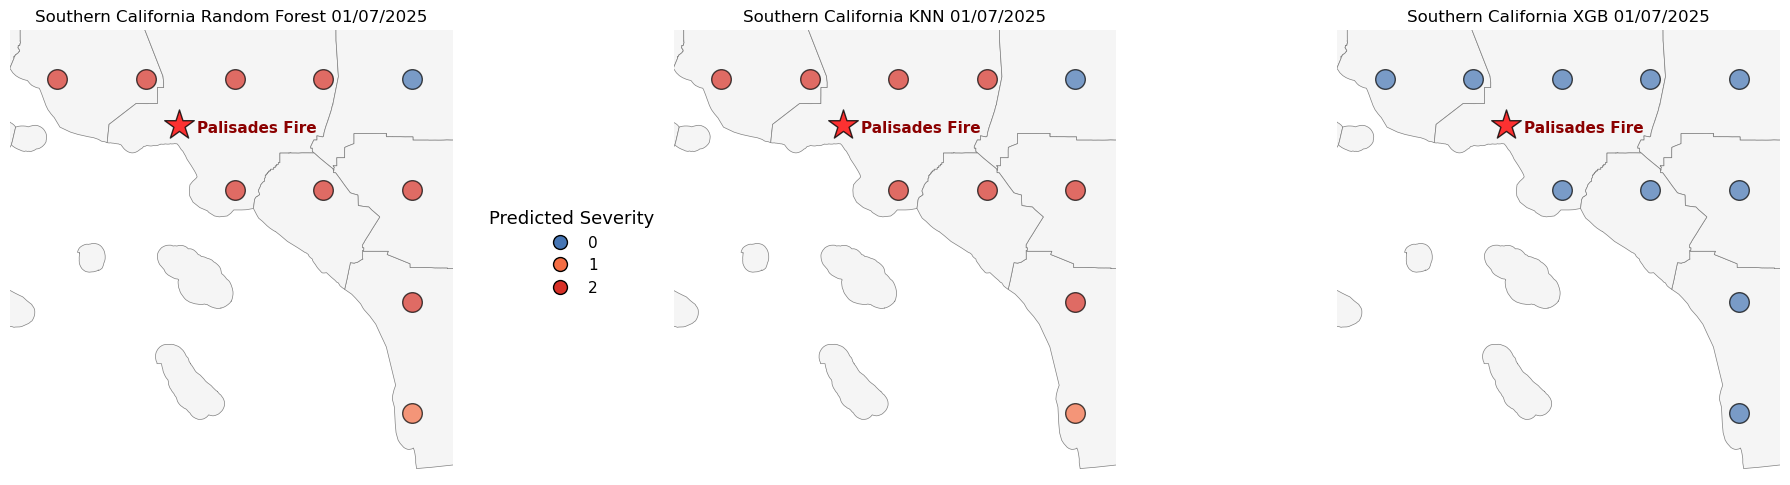

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))  # 1 row, 3 columns

# Plot into each subplot by passing in the axis
plot_map(pal_gdf, 'Prediction RF', 'Palisades', ax=axes[0])
plot_map(pal_gdf, 'Prediction KNN', 'Palisades', ax=axes[1])
plot_map(pal_gdf, 'Prediction XGB', 'Palisades', ax=axes[2])

# Set titles if plot_map doesn't do it
axes[0].set_title('Southern California Random Forest 01/07/2025')
axes[1].set_title('Southern California KNN 01/07/2025')
axes[2].set_title('Southern California XGB 01/07/2025')

plt.tight_layout()

plt.savefig("../plots/Palisades_predictions.png", dpi=300)

### Interpolation

<img src="../data/maps/IDW_RF.jpg" width="600">